# Discriminative Classifiers - Diagnosing Breast Cancer

In this practical, we will work with a real dataset of medical data. The features are generated from images of masses taken from breast tissue. The outcome variable is whether the mass is malignant or benign. More information can be found [here](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29).

We will use a train/test split to explore the impact of the $k$ on performance, looking at the trade-off between bias and variance. We will also look at how the KNN model is sensitive to the values of the features you use.

First, we load the data into a DataFrame and assign the features to `X` and the `diagnosis` variable to `y`.

Look at the distribution of benign (`y==0`) and malignant (`y==1`). What do you notice?

In [1]:
import pandas as pd

data = pd.read_csv("data/wisconsin_data.csv")
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

# Your thoughts here...
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Creating a test/train split

Split the data into train and test datasets. You could do this manually but the `sklearn.model_selection.train_test_split` function can handle it all. It takes in data `X` and `y` and splits it into `X_train`, `X_test`, `y_train` and `y_test`.

Use this function to split up your data. Make the test set contain around 20% of the data using `test_size=0.2`.

Set `stratify=y` to ensure the ratio of classes in `y_train`/`y_test` is preserved and check this is the case.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# check the proportion
print("Original:  ", pd.Series(y).value_counts(normalize=True).values)
print("Train set: ", pd.Series(y_train).value_counts(normalize=True).values)
print("Test set:  ", pd.Series(y_test).value_counts(normalize=True).values)


Original:   [0.62741652 0.37258348]
Train set:  [0.62637363 0.37362637]
Test set:   [0.63157895 0.36842105]


## Training an initial model

Instantiate a `sklearn.neighbors.KNeighborsClassifier` model with default parameters (`k=5`), named `knn`.

Use the `.fit()` method to train it on `X_train` and `y_train`.

Use the `.score()` method of the trained model to find its accuracy using the test set `X_test` and `y_test`

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Your code here...

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
knn.score(X_test, y_test)

0.9122807017543859

## Pre-processing data for optimal KNN performance

Because KNN uses the concept of **distance** between points to determine similarity, if the scales of features differ wildly then it can cause issues.

For example, if one feature is in the range 1-5, but another in the 400 to 290000, then the Euclidean spaces represented by these features are very far apart. Distances between two points based on these features will be extreme.

The min/max of `X_train` shows this:

In [4]:
X_train.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,14.166077,19.417692,92.215868,659.578242,0.095993,0.103835,0.089184,0.049015,0.181497,0.062715,...,16.351514,25.904879,107.860484,890.569231,0.132083,0.255529,0.275166,0.115491,0.291364,0.084124
std,3.579081,4.290653,24.717118,360.418686,0.014310,0.053910,0.081698,0.039686,0.027646,0.006971,...,4.901037,6.079532,34.176019,582.346181,0.023481,0.158400,0.212066,0.066844,0.063043,0.018169
min,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.106000,0.050240,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.710000,16.335000,75.235000,420.400000,0.085130,0.063735,0.029520,0.019685,0.162050,0.057635,...,13.020000,21.490000,84.135000,516.150000,0.114550,0.147750,0.119350,0.064075,0.251200,0.071365
50%,13.340000,18.900000,86.180000,546.400000,0.095240,0.092280,0.059400,0.033340,0.179900,0.061300,...,14.920000,25.480000,97.650000,683.400000,0.131100,0.216700,0.229800,0.101000,0.282300,0.080090
75%,15.935000,21.830000,104.500000,795.500000,0.104900,0.130350,0.132200,0.074075,0.195400,0.066370,...,19.185000,30.200000,127.000000,1122.500000,0.146600,0.338100,0.385700,0.162100,0.318700,0.092085
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


It is not the raw feature values that matter, but their size relative to each other. Therefore, we can scale all features to be within the same range. This is normally 0 to 1.

This can be easily done using `sklearn.preprocessing.MinMaxScaler`:



In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"New min: {X_train_scaled.min():.3f} New max: {X_train_scaled.max():.3f}")

New min: 0.000 New max: 1.000


Train and score a new KNN as before, named `knn_scaled`, using the new scaled data.

In [6]:
# Your code here...
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
knn_scaled.score(X_test_scaled, y_test)

0.956140350877193

Accuracy has improved quite a bit!

## The impact of `k` on accuracy

Recall that the value of $k$ in KNN impacts model **bias** (how well the model captures relevant relations in the features) and model **variance** (how sensitive the model is to noise in the features).

A KNN model is most prone to overfitting when $k$ is low, and underfitting when $k$ is high.

For values of $k$ in `range(1, 400)`, create a model using that value of $k$ and `.fit()` it using `X_train_scaled` and `y_train`.

Use the `.score()` method on the train data (`X_train_scaled` and `y_train`) and store the resulting score in `accs_train`.

Use the `.score()` method on the test data (`X_test_scaled` and `y_test`) and store the resulting score in `accs_test`.

(This might take 30 seconds or so to complete!)

In [7]:
accs_train = []
accs_test = []

# Your code here...
for k in range(1,400):
    knn_scaled = KNeighborsClassifier(n_neighbors=k)
    knn_scaled.fit(X_train_scaled, y_train)
    accs_train.append(knn_scaled.score(X_train_scaled, y_train))
    accs_test.append(knn_scaled.score(X_test_scaled, y_test))
    

The cell below will plot the results for you, of accuracy at various values of $k$. What do you observe?

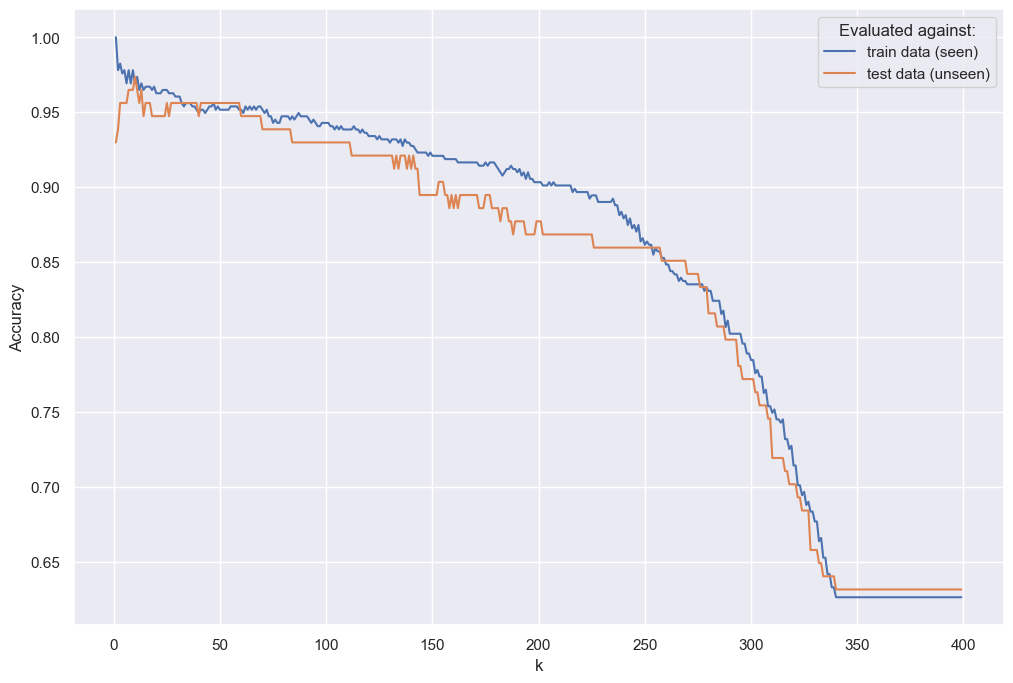

In [8]:
import seaborn as sns

# Make plot a readable size
sns.set_theme(rc={"figure.figsize": (12, 8)})
# Convert data to DataFrame
df = pd.DataFrame(
    zip(accs_train, accs_test, range(1, 400)),
    columns=["train data (seen)", "test data (unseen)", "k"],
)
# Melt to long format for easy plotting
df = df.melt(var_name="Evaluated against:", id_vars="k", value_name="Accuracy")
# Plot dataframe
g = sns.lineplot(data=df, hue="Evaluated against:", x="k", y="Accuracy")


# Your thoughts here...


## Evaluating KNN: true/false positives/negatives

The `.score()` method used the accuracy metric - the number of correct classifications out of the total classifications made.

This doesn't really give the best picture of model performance, though. As you saw when $k>350$, accuracy flat-lines at 0.63. This is because the model is using almost ALL the other data points for classification and around 63% of them are in the benign class.

A more useful approach is to see how the model performed for each individual class. Especially for health-related tasks, we are interested in:

* True Positives (TP): Cases in which the tissue is malignant and it was predicted as such.
* True Negatives (TN): Cases in which the tissue is benign (not malignant) and it was predicted as such.
* False Positives (FP): Cases in which the tissue is benign (not malignant) and it was predicted as malignant. (This is often called Type I error.)
* False Negatives (FN): Cases in which the tissue is malignant and it was predicted as benign. (This is often called Type II error.)

A confusion matrix can show this and can be computed using `pandas.crosstab` then visualised with `seaborn.heatmap`.

The cell below will do this for you. What do you observe?

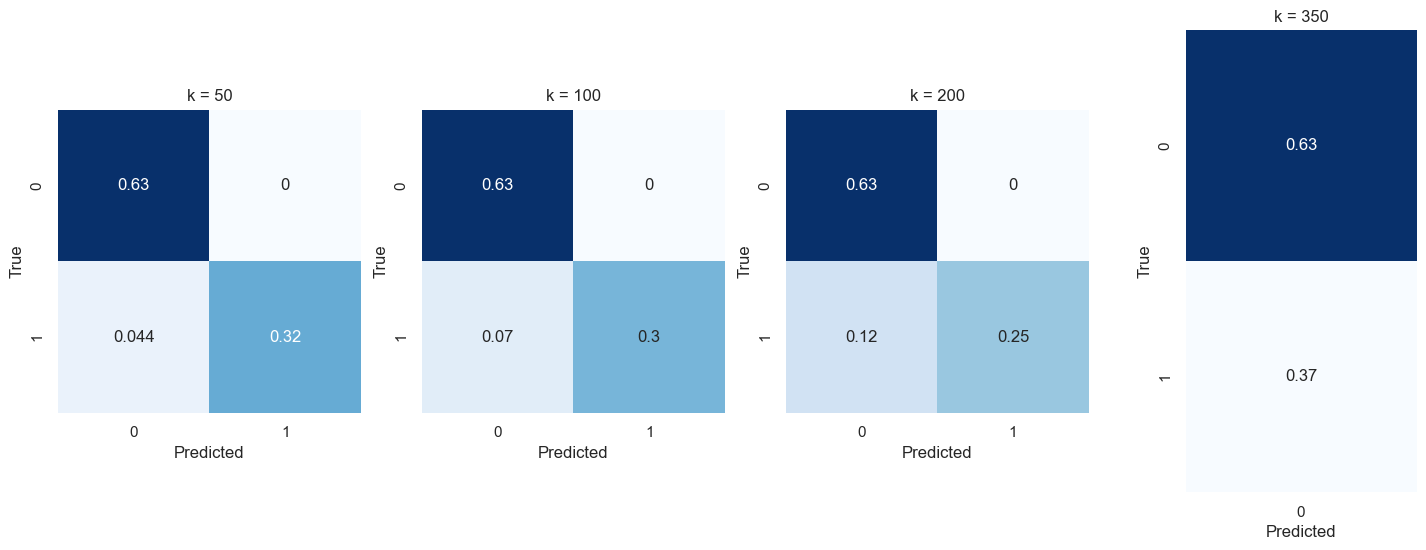

In [9]:
import matplotlib.pyplot as plt

# Make readable size
sns.set_theme(rc={"figure.figsize": (18, 6)})
# Get 4 new blank plots in a row
fig, axes = plt.subplots(1, 4)

# Iterate through a few values of k
for e, k in enumerate([50, 100, 200, 350]):
    # Make model
    knn = KNeighborsClassifier(n_neighbors=k)
    # Train on training data
    knn.fit(X_train_scaled, y_train)
    # Get predictions of test data
    y_pred = knn.predict(X_test_scaled)

    # Make the confusion matrix. Normalise the cells to show percentages overall
    cm = pd.crosstab(
        y_test, y_pred, rownames=["True"], colnames=["Predicted"], normalize=True
    )

    # Plot confusion matrix, one on each of the blank axes.
    g = sns.heatmap(
        data=cm, cmap="Blues", square=True, annot=True, ax=axes[e], cbar=False
    )

    # Label them so it's clear which is which
    g.set_title(f"k = {k}")


# Your thoughts here...


## Evaluating KNN: precision, recall, F1 score

True/false positives/negatives can be combined to make new metrics, to give a more concise understanding of how the model is performing.

* Precision = TP/TP+FP
    * Ratio of correctly predicted positive observations to the total predicted positive observations
* Recall = TP/TP+FN
    * Ratio of correctly predicted positive observations to all of the observations in that class
* F1 Score = 2*(Recall Precision) / (Recall + Precision)
    * Weighted average of Precision and Recall
    
`sklearn.metrics.classification_report` can provide a nice summary of all of these metrics, per class.

For values of `k` in `[50,100,200,350]`, train and fit a new model on the scaled training data.

Use the model's `.predict()` method with the scaled test data. Store as `y_pred`.

Use `classification_report(y_test, y_pred, zero_division=0)` to calculate metrics for the model and print them out.

(Note: `zero_division=0` will prevent an error from popping up when precision or recall equal 0.)

What do you observe?

In [10]:
from sklearn.metrics import classification_report

# Your code and thoughts below...
for k in [50, 100, 200, 350]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(f"Classification report for k={k}:\n")
    print(classification_report(y_test, y_pred))

Classification report for k=50:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification report for k=100:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        72
           1       1.00      0.81      0.89        42

    accuracy                           0.93       114
   macro avg       0.95      0.90      0.92       114
weighted avg       0.94      0.93      0.93       114

Classification report for k=200:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        72
           1       1.00      0.67      0.80        42

    accuracy                           0.88       114
   macro avg       0.92    

/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

# Conclusion

In this section you trained evaluated a KNN model for diagnosing breast cancer.

You could also look more into the evaluation metrics for these classifiers. See [the sklearn documentation](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) for a range of classification metrics.